In [2]:
# 2.1 Import the data file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
log = pd.read_csv('aviation_log.csv')

In [4]:
# 2.2 Change column headings
log = log.rename(columns={
    'Location': 'Incident_Location',
    'Operator': 'Airline_Operator',
    'Type': 'Aircraft_Type',
    'Registration': 'Registration_Number',
    'Aboard': 'People_Aboard',
    'Fatalities': 'Fatalities_Aboard',
    'Ground': 'Ground_Fatalities',
    'Summary': 'Event_Info'
})

In [6]:
# 2.3 Determine row count, column count and total elements
row_count = log.shape[0]
column_count = log.shape[1]
total_elements = row_count * column_count

print(f"Row count: {row_count}")
print(f"Column count: {column_count}")
print(f"Total elements: {total_elements}")

Row count: 5268
Column count: 13
Total elements: 68484


In [8]:
# 2.4 Inspect the data
# Display first 10 records
print("\nFirst 10 records:")
print(log.head(10))

# Generate statistical summary
print("\nStatistical summary:")
print(log.describe())

# Display data types
print("\nData types:")
print(log.dtypes)


First 10 records:
         Date   Time                   Incident_Location  \
0  09/17/1908  17:18                 Fort Myer, Virginia   
1  07/12/1912  06:30             AtlantiCity, New Jersey   
2  08/06/1913    NaN  Victoria, British Columbia, Canada   
3  09/09/1913  18:30                  Over the North Sea   
4  10/17/1913  10:30          Near Johannisthal, Germany   
5  03/05/1915  01:00                     Tienen, Belgium   
6  09/03/1915  15:20               Off Cuxhaven, Germany   
7  07/28/1916    NaN               Near Jambol, Bulgeria   
8  09/24/1916  01:00                 Billericay, England   
9  10/01/1916  23:45                Potters Bar, England   

         Airline_Operator Flight #          Route  \
0    Military - U.S. Army      NaN  Demonstration   
1    Military - U.S. Navy      NaN    Test flight   
2                 Private        -            NaN   
3  Military - German Navy      NaN            NaN   
4  Military - German Navy      NaN            NaN   
5 

In [10]:
# 2.5 Change the data type of Date column to DateTime
log['Date'] = pd.to_datetime(log['Date'])

In [12]:
# 2.6 Split the Date column into Year, Month, and Day
# Insert the columns between Date and Time
log.insert(loc=log.columns.get_loc('Date') + 1, column='Year', value=log['Date'].dt.year)
log.insert(loc=log.columns.get_loc('Year') + 1, column='Month', value=log['Date'].dt.month)
log.insert(loc=log.columns.get_loc('Month') + 1, column='Day', value=log['Date'].dt.day)

# Display the updated dataframe columns
print("\nUpdated columns after adding Year, Month, Day:")
print(log.columns.tolist())


Updated columns after adding Year, Month, Day:
['Date', 'Year', 'Month', 'Day', 'Time', 'Incident_Location', 'Airline_Operator', 'Flight #', 'Route', 'Aircraft_Type', 'Registration_Number', 'cn/In', 'People_Aboard', 'Fatalities_Aboard', 'Ground_Fatalities', 'Event_Info']


In [14]:
# 2.7 Add the Total_Fatalities column
log['Total_Fatalities'] = log['Fatalities_Aboard'] + log['Ground_Fatalities']

# 2.7.1 Maximum number of Total Fatalities
max_fatalities = log['Total_Fatalities'].max()
print(f"\nMaximum number of Total Fatalities: {max_fatalities}")


Maximum number of Total Fatalities: 2842.0


In [16]:
# 2.7.2 Date of the crash with maximum fatalities
max_fatalities_crash = log[log['Total_Fatalities'] == max_fatalities]
crash_date = max_fatalities_crash['Date'].iloc[0]
print(f"Date of the crash with maximum fatalities: {crash_date}")

Date of the crash with maximum fatalities: 2001-09-11 00:00:00


In [18]:
# 2.7.3 Event information about the crash with maximum fatalities
event_info = max_fatalities_crash['Event_Info'].iloc[0]
print(f"Event info: {event_info}")

Event info: The aircraft was hijacked shortly after it left Logan International Airport in Boston. The hijackers took control of the aircraft and deliberately crashed it into the north tower of the World Trade Center between the 94th and 99th floors at approximately 450 mph.  After 102 minutes, the building collapsed. It was one of four planes that were hijacked the same day.


In [20]:
# 2.8 Top 20 Airline Operators with the most crashes
operator_crashes = log['Airline_Operator'].value_counts().head(20)
print("\nTop 20 Airline Operators with most crashes:")
print(operator_crashes)


Top 20 Airline Operators with most crashes:
Airline_Operator
Aeroflot                               179
Military - U.S. Air Force              176
Air France                              70
Deutsche Lufthansa                      65
Air Taxi                                44
China National Aviation Corporation     44
United Air Lines                        44
Military - U.S. Army Air Forces         43
Pan American World Airways              41
Military - U.S. Navy                    36
American Airlines                       36
US Aerial Mail Service                  36
Military - Royal Air Force              36
Indian Airlines                         34
KLM Royal Dutch Airlines                33
Philippine Air Lines                    33
Private                                 31
Aeropostale                             26
Northwest Orient Airlines               25
Eastern Air Lines                       25
Name: count, dtype: int64


In [22]:
# 2.9 Percentage of crashes involving South African Airways
total_crashes = len(log)
sa_airways_crashes = len(log[log['Airline_Operator'] == 'South African Airways'])
sa_percentage = round((sa_airways_crashes / total_crashes) * 100, 2)
print(f"\nPercentage of crashes involving South African Airways: {sa_percentage}%")


Percentage of crashes involving South African Airways: 0.11%


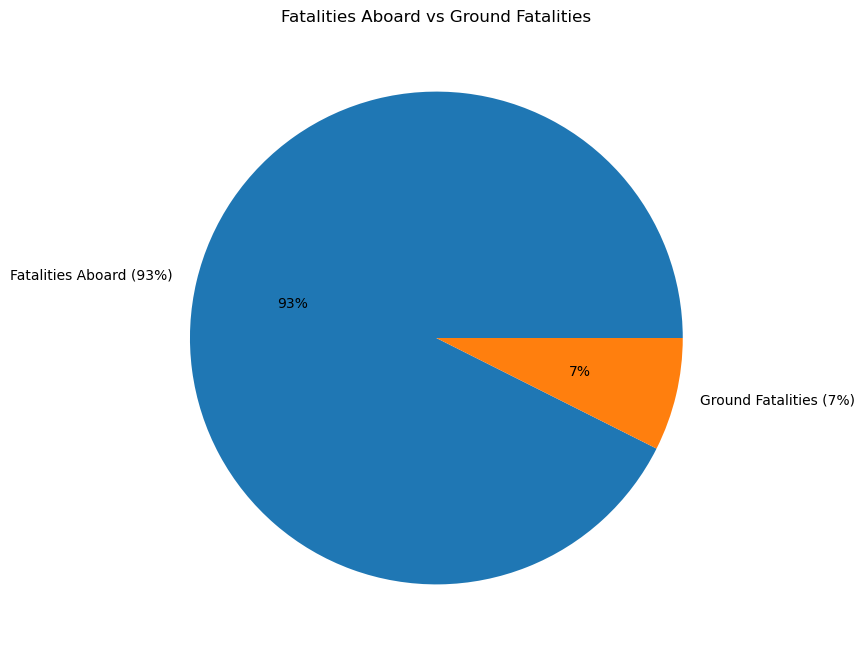

In [24]:
# 2.10 Pie chart of Fatalities Aboard versus Ground Fatalities
total_fatalities_aboard = log['Fatalities_Aboard'].sum()
total_ground_fatalities = log['Ground_Fatalities'].sum()
fatalities_data = [total_fatalities_aboard, total_ground_fatalities]
labels = [f'Fatalities Aboard ({round(total_fatalities_aboard/(total_fatalities_aboard+total_ground_fatalities)*100)}%)', 
          f'Ground Fatalities ({round(total_ground_fatalities/(total_fatalities_aboard+total_ground_fatalities)*100)}%)']

plt.figure(figsize=(8, 8))
plt.pie(fatalities_data, labels=labels, autopct='%1.0f%%')
plt.title('Fatalities Aboard vs Ground Fatalities')
plt.show()

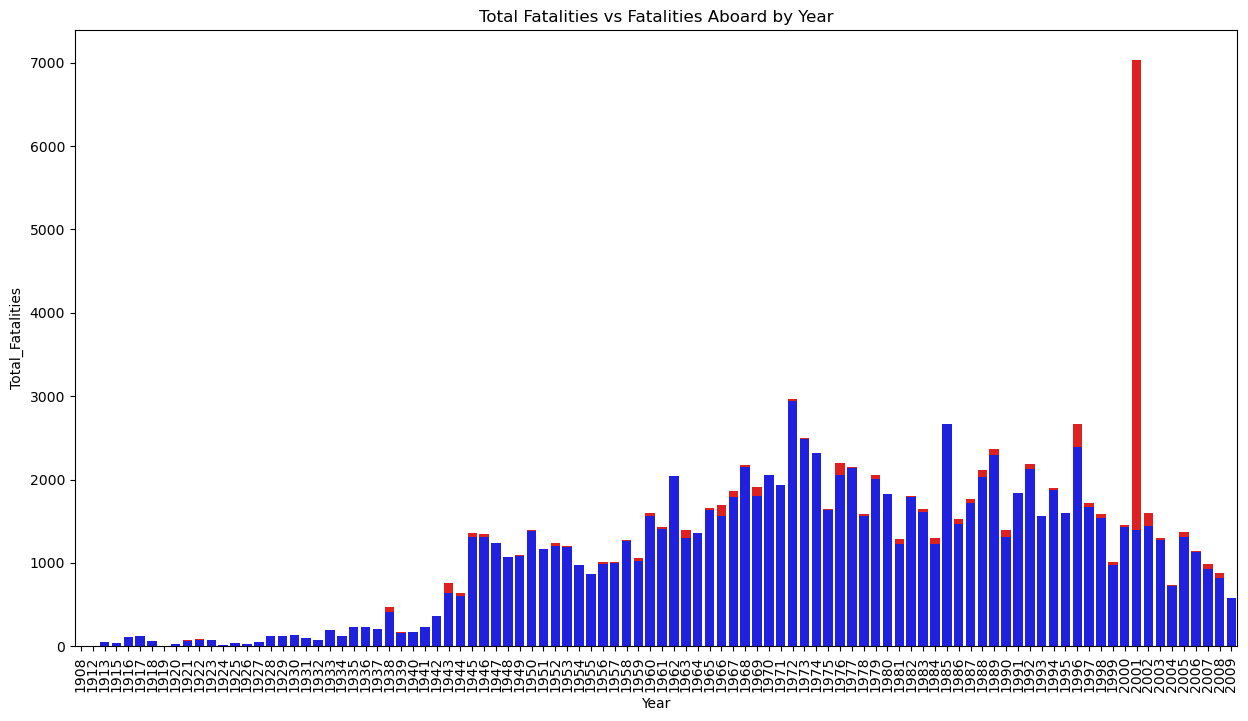

In [26]:
# 2.11 Deduction from pie chart
# [Would be a written response based on the actual pie chart]

# 2.12 Seaborn bar charts for Total Fatalities and Fatalities Aboard per year
yearly_totals = log.groupby('Year')[['Total_Fatalities', 'Fatalities_Aboard']].sum().reset_index()

plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Year', y='Total_Fatalities', data=yearly_totals, color='red')
sns.barplot(x='Year', y='Fatalities_Aboard', data=yearly_totals, color='blue')
plt.title('Total Fatalities vs Fatalities Aboard by Year')
plt.xticks(rotation=90)
plt.show()

In [28]:
# 2.13 Discussion about bar chart and pie chart
# [Would be a written response based on the actual charts]

# 2.14 Aircraft Type with highest sum of Fatalities Aboard
aircraft_fatalities = log.groupby('Aircraft_Type')['Fatalities_Aboard'].sum().reset_index()
highest_fatality_aircraft = aircraft_fatalities.sort_values('Fatalities_Aboard', ascending=False).head(1)
print(f"\nAircraft Type with highest Fatalities Aboard: {highest_fatality_aircraft['Aircraft_Type'].iloc[0]}")
print(f"Total Fatalities Aboard: {highest_fatality_aircraft['Fatalities_Aboard'].iloc[0]}")



Aircraft Type with highest Fatalities Aboard: Douglas DC-3
Total Fatalities Aboard: 4793.0


In [30]:
# 2.15 Discard specified columns
columns_to_drop = ['Date', 'Time', 'Flight #', 'Route', 'Registration_Number', 'cn/In', 'Event_Info']
log = log.drop(columns=columns_to_drop)

# Display remaining columns
print("\nRemaining columns after dropping specified ones:")
print(log.columns.tolist())


Remaining columns after dropping specified ones:
['Year', 'Month', 'Day', 'Incident_Location', 'Airline_Operator', 'Aircraft_Type', 'People_Aboard', 'Fatalities_Aboard', 'Ground_Fatalities', 'Total_Fatalities']


In [32]:
# 2.16 Handle missing values
# Check for missing values
print("\nMissing values before cleaning:")
print(log.isnull().sum())


Missing values before cleaning:
Year                  0
Month                 0
Day                   0
Incident_Location    20
Airline_Operator     18
Aircraft_Type        27
People_Aboard        22
Fatalities_Aboard    12
Ground_Fatalities    22
Total_Fatalities     22
dtype: int64


In [34]:
# Discard rows with missing values
log = log.dropna()

# Check if missing values were discarded
print("\nMissing values after cleaning:")
print(log.isnull().sum())


Missing values after cleaning:
Year                 0
Month                0
Day                  0
Incident_Location    0
Airline_Operator     0
Aircraft_Type        0
People_Aboard        0
Fatalities_Aboard    0
Ground_Fatalities    0
Total_Fatalities     0
dtype: int64


In [36]:
# 2.17 Convert text values to numeric
# For Airline_Operator and Aircraft_Type
from sklearn.preprocessing import LabelEncoder

le_operator = LabelEncoder()
log['Airline_Operator'] = le_operator.fit_transform(log['Airline_Operator'])

le_aircraft = LabelEncoder()
log['Aircraft_Type'] = le_aircraft.fit_transform(log['Aircraft_Type'])

# For Incident_Location
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
location_encoded = vectorizer.fit_transform(log['Incident_Location'].astype(str))
location_df = pd.DataFrame(location_encoded.toarray(), columns=vectorizer.get_feature_names_out())

# Drop original location column and join with vectorized features
log = log.drop('Incident_Location', axis=1)
log = pd.concat([log.reset_index(drop=True), location_df.reset_index(drop=True)], axis=1)

In [38]:
# 2.18 Scale values (excluding Year, Month, Day)
from sklearn.preprocessing import StandardScaler

# Identify columns to scale (all numeric columns except Year, Month, Day)
cols_to_scale = [col for col in log.columns if col not in ['Year', 'Month', 'Day']]

# Apply scaling
scaler = StandardScaler()
log[cols_to_scale] = scaler.fit_transform(log[cols_to_scale])

In [40]:
# 2.19 Write the cleaned dataframe to CSV
log.to_csv('clean_aviation_log.csv', index=False)
print("\nCleaned data saved to 'clean_aviation_log.csv'")


Cleaned data saved to 'clean_aviation_log.csv'
